# Notebook 3 : Model 1B - Skin Concern
### Skincare Risk Assement System| Skin Type & Concern

## **Concern prediciton**
For concern Prediction we used ingredient and skin types

<a id='1'></a>
## Imports & loading

In this part, we begin by importing some of the required libraries, and load the df and matrices

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
from scipy.sparse import load_npz, csr_matrix, hstack
from sklearn.preprocessing import LabelEncoder

PATH = '/content/drive/MyDrive/ps2_v2/data/'

# Load df
skincare1 = pd.read_csv(PATH + 'skincare1_clean.csv')
print(f"skincare1: {skincare1.shape}")
print(f"Columns: {skincare1.columns.tolist()}")

# Load TF-IDF matrix
X_tfidf = load_npz(PATH + 'X_tfidf.npz')
print(f"X_tfidf: {X_tfidf.shape}")

# Load product OHE matrix
X_product = load_npz(PATH + 'X_product.npz')
print(f"X_product: {X_product.shape}")

# Load encoders
with open(PATH + 'tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
with open(PATH + 'ohe_product.pkl', 'rb') as f:
    ohe_product = pickle.load(f)

print("Encoders loaded")

# 6 classes — Anti-aging merged into Hyperpigmentation in notebook 1
# LabelEncoder assigns alphabetically:
# Acne=0, Dryness=1, Eczema=2, Hyperpigmentation=3, Redness=4, Sensitivity=5
concern_classes = ['Acne', 'Dryness', 'Eczema',
                   'Hyperpigmentation', 'Redness', 'Sensitivity']
print(f"Concern classes ({len(concern_classes)}): {concern_classes}")

# Use concern_encoded directly — already integers from notebook 1
y_concern = skincare1['concern_encoded'].values
print(f"\ny_concern unique values: {np.unique(y_concern)}")
print(f"\ny_concern distribution:")
for i, cls in enumerate(concern_classes):
    count = (y_concern == i).sum()
    pct   = count / len(y_concern) * 100
    print(f"  {i} → {cls:<22} {count:>4}  ({pct:.1f}%)")

Mounted at /content/drive
skincare1: (9510, 10)
Columns: ['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive', 'primary_concern', 'age_group', 'product_type', 'age_encoded', 'concern_encoded']
X_tfidf: (9510, 500)
X_product: (9510, 16)
Encoders loaded
Concern classes (6): ['Acne', 'Dryness', 'Eczema', 'Hyperpigmentation', 'Redness', 'Sensitivity']

y_concern unique values: [0 1 2 3 4 5]

y_concern distribution:
  0 → Acne                   4215  (44.3%)
  1 → Dryness                 399  (4.2%)
  2 → Eczema                 1299  (13.7%)
  3 → Hyperpigmentation      2046  (21.5%)
  4 → Redness                 736  (7.7%)
  5 → Sensitivity             815  (8.6%)


In [3]:
from google.colab import files
files.download('/content/drive/MyDrive/ps2_v2/data/ohe_product.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
temp = pd.read_csv(PATH + 'skincare1_clean.csv')
print(temp.columns.tolist())
print(temp.shape)

['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive', 'primary_concern', 'age_group', 'product_type', 'age_encoded', 'concern_encoded']
(9510, 10)


### **Data splitting**

In [5]:
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split

# Model 1B: X = TF-IDF + product type (NO skin type → leakage)
X_concern = X_tfidf
y_concern  = skincare1['concern_encoded'].values

X_concern_train, X_concern_test, \
y_concern_train, y_concern_test = train_test_split(
    X_concern, y_concern,
    test_size=0.2,
    random_state=42,
    stratify=y_concern
)

print(f"X_concern_train: {X_concern_train.shape}")
print(f"X_concern_test:  {X_concern_test.shape}")
print(f"\nClass distribution in train:")
for i, cls in enumerate(concern_classes):
    count = (y_concern_train == i).sum()
    pct   = count / len(y_concern_train) * 100
    print(f"  {cls:<22} → {count:>4}  ({pct:.1f}%)")

X_concern_train: (7608, 500)
X_concern_test:  (1902, 500)

Class distribution in train:
  Acne                   → 3372  (44.3%)
  Dryness                →  319  (4.2%)
  Eczema                 → 1039  (13.7%)
  Hyperpigmentation      → 1637  (21.5%)
  Redness                →  589  (7.7%)
  Sensitivity            →  652  (8.6%)


### **Metrics function**

In [6]:

from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix,
    balanced_accuracy_score

)

def evaluate_multiclass(y_true, y_pred, model_name, class_names):
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_ma = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"  Model:        {model_name}")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  Balanced Accuracy:  {bal_acc:.4f}")
    print(f"  F1 Weighted:  {f1_w:.4f}")
    print(f"  F1 Macro:     {f1_ma:.4f}")
    print()

    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
    for cls, score in zip(class_names, f1_per):
        print(f"  {cls:20} F1: {score:.3f}")
    print()

## **Baseline Models Training**

### **Random forest**

In [7]:

from sklearn.ensemble import RandomForestClassifier

model_1B_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_1B_rf.fit(X_concern_train, y_concern_train)

y_concern_pred_rf_train = model_1B_rf.predict(X_concern_train)
y_concern_pred_rf_test  = model_1B_rf.predict(X_concern_test)

print("="*50)
print("MODEL 1B — Random Forest")
print("="*50)

print("Training Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_train,
    y_concern_pred_rf_train,
    "Random Forest - Train",
    concern_classes
)

print("\nTesting Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_test,
    y_concern_pred_rf_test,
    "Random Forest - Test",
    concern_classes
)

MODEL 1B — Random Forest
Training Performance
  Model:        Random Forest - Train
  Accuracy:     0.9980
  Balanced Accuracy:  0.9980
  F1 Weighted:  0.9980
  F1 Macro:     0.9958

  Acne                 F1: 0.999
  Dryness              F1: 0.983
  Eczema               F1: 0.999
  Hyperpigmentation    F1: 0.998
  Redness              F1: 0.997
  Sensitivity          F1: 0.998


Testing Performance
  Model:        Random Forest - Test
  Accuracy:     0.8975
  Balanced Accuracy:  0.8166
  F1 Weighted:  0.8973
  F1 Macro:     0.8364

  Acne                 F1: 0.971
  Dryness              F1: 0.698
  Eczema               F1: 0.919
  Hyperpigmentation    F1: 0.856
  Redness              F1: 0.812
  Sensitivity          F1: 0.763



## **Logistic regression**

In [8]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform, randint
model_1B_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model_1B_lr.fit(X_concern_train, y_concern_train)

y_concern_pred_lr_train = model_1B_lr.predict(X_concern_train)
y_concern_pred_lr_test  = model_1B_lr.predict(X_concern_test)

print("="*50)
print("MODEL 1B — Logistic Regression")
print("="*50)

print("Training Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_train,
    y_concern_pred_lr_train,
    "Logistic Regression - Train",
    concern_classes
)

print("\nTesting Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_test,
    y_concern_pred_lr_test,
    "Logistic Regression - Test",
    concern_classes
)

MODEL 1B — Logistic Regression
Training Performance
  Model:        Logistic Regression - Train
  Accuracy:     0.8883
  Balanced Accuracy:  0.9068
  F1 Weighted:  0.8915
  F1 Macro:     0.8551

  Acne                 F1: 0.940
  Dryness              F1: 0.773
  Eczema               F1: 0.874
  Hyperpigmentation    F1: 0.866
  Redness              F1: 0.832
  Sensitivity          F1: 0.845


Testing Performance
  Model:        Logistic Regression - Test
  Accuracy:     0.8391
  Balanced Accuracy:  0.8289
  F1 Weighted:  0.8457
  F1 Macro:     0.7820

  Acne                 F1: 0.925
  Dryness              F1: 0.625
  Eczema               F1: 0.829
  Hyperpigmentation    F1: 0.808
  Redness              F1: 0.769
  Sensitivity          F1: 0.736



**Logistic Regression confusion matrix**

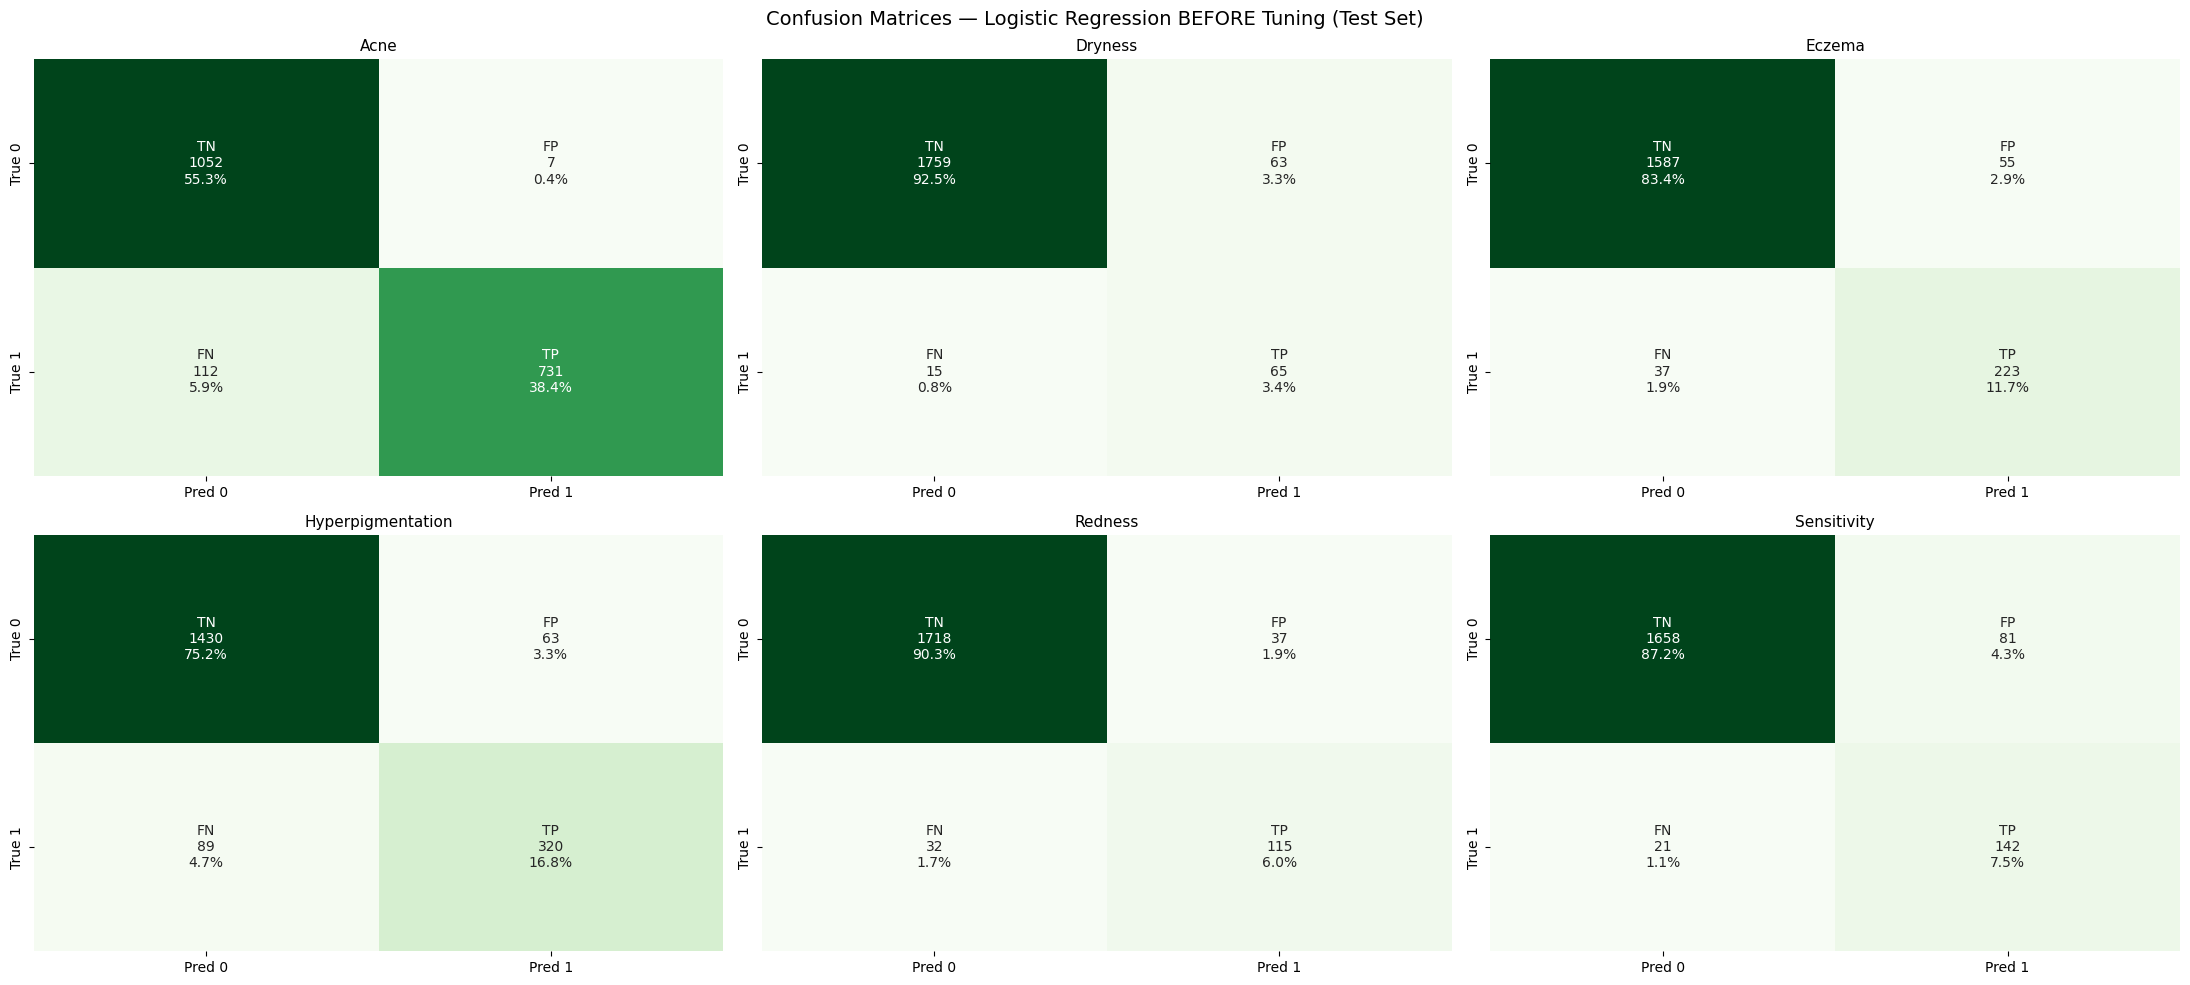

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()

for i, concern in enumerate(concern_classes):
    y_true_bin = (y_concern_test == i).astype(int)
    y_pred_bin = (y_concern_pred_lr_test == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    group_names  = ['TN', 'FP', 'FN', 'TP']
    group_counts = [f"{v}" for v in cm.flatten()]
    group_pct    = [f"{v:.1%}" for v in cm.flatten() / cm.sum()]
    labels = [f"{n}\n{c}\n{p}" for n, c, p
              in zip(group_names, group_counts, group_pct)]
    labels = np.array(labels).reshape(2, 2)

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        ax=axes[i],
        cmap='Greens',
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1']
    )
    axes[i].set_title(f'{concern}', fontsize=11)

# hide last empty subplot (12 concerns, 3x4=12 fits exactly)
if len(concern_classes) < len(axes):
    for j in range(len(concern_classes), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Logistic Regression BEFORE Tuning (Test Set)',
             fontsize=14)
plt.tight_layout()
plt.savefig('cm_lr_before_tuning.png', dpi=150)
plt.show()

The Logistic Regression model performs very well on predicting skin conditions ,
It is particularly reliable at avoiding false positives, with near-perfect results on Dermatitis, while Eczema and Vitiligo have slightly higher false negatives.


### **Linear Svm**

In [10]:
from sklearn.svm import LinearSVC

model_1B_svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)
model_1B_svm.fit(X_concern_train, y_concern_train)

y_concern_pred_svm_train = model_1B_svm.predict(X_concern_train)
y_concern_pred_svm_test  = model_1B_svm.predict(X_concern_test)

print("="*50)
print("MODEL 1B — Linear SVM")
print("="*50)

print("Training Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_train,
    y_concern_pred_svm_train,
    "Linear SVM - Train",
    concern_classes
)

print("\nTesting Performance")
print("=" * 30)
evaluate_multiclass(
    y_concern_test,
    y_concern_pred_svm_test,
    "Linear SVM - Test",
    concern_classes
)

MODEL 1B — Linear SVM
Training Performance
  Model:        Linear SVM - Train
  Accuracy:     0.9363
  Balanced Accuracy:  0.9362
  F1 Weighted:  0.9374
  F1 Macro:     0.9133

  Acne                 F1: 0.971
  Dryness              F1: 0.877
  Eczema               F1: 0.935
  Hyperpigmentation    F1: 0.919
  Redness              F1: 0.897
  Sensitivity          F1: 0.881


Testing Performance
  Model:        Linear SVM - Test
  Accuracy:     0.8843
  Balanced Accuracy:  0.8406
  F1 Weighted:  0.8877
  F1 Macro:     0.8226

  Acne                 F1: 0.966
  Dryness              F1: 0.667
  Eczema               F1: 0.906
  Hyperpigmentation    F1: 0.843
  Redness              F1: 0.801
  Sensitivity          F1: 0.753



### **Linear svm confusion matrix**

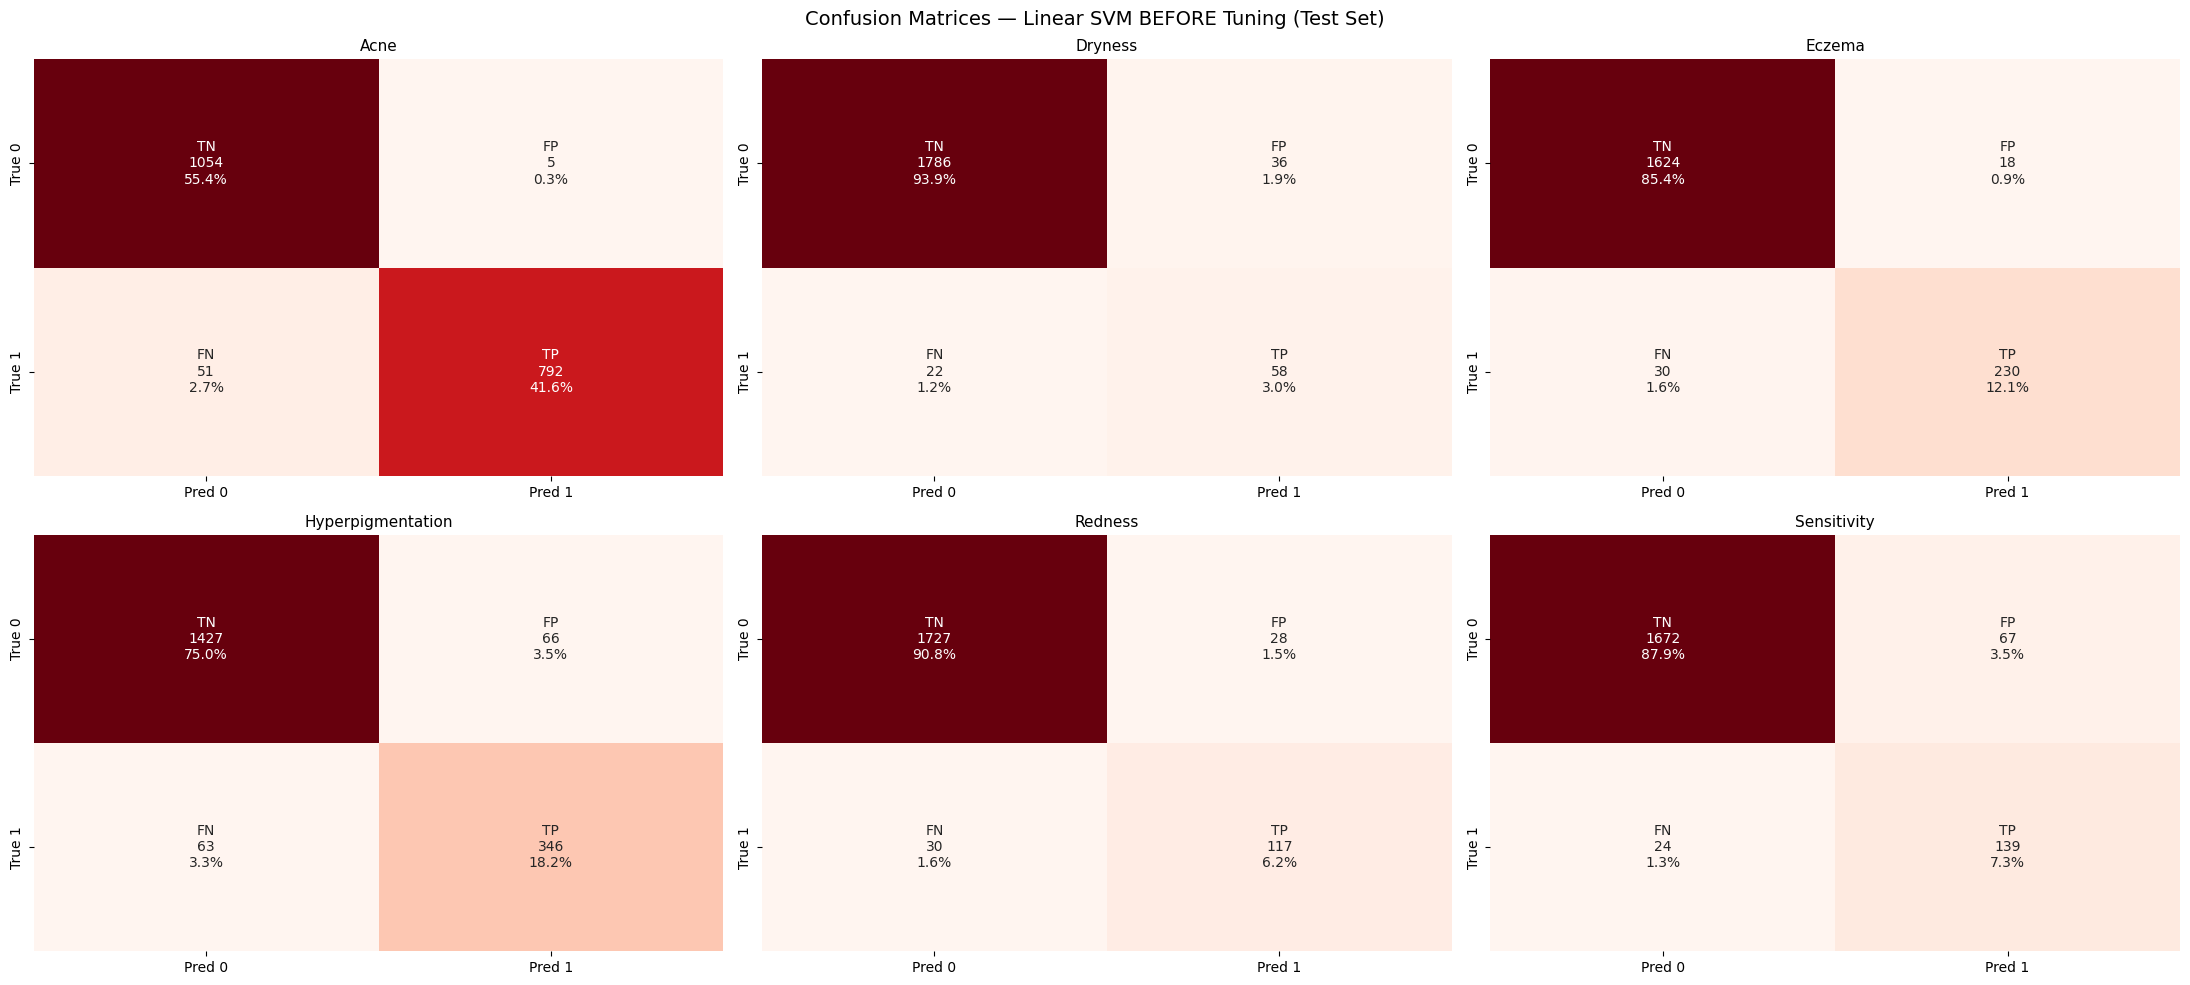

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()

for i, concern in enumerate(concern_classes):
    y_true_bin = (y_concern_test == i).astype(int)
    y_pred_bin = (y_concern_pred_svm_test == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    group_names  = ['TN', 'FP', 'FN', 'TP']
    group_counts = [f"{v}" for v in cm.flatten()]
    group_pct    = [f"{v:.1%}" for v in cm.flatten() / cm.sum()]
    labels = [f"{n}\n{c}\n{p}" for n, c, p
              in zip(group_names, group_counts, group_pct)]
    labels = np.array(labels).reshape(2, 2)

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        ax=axes[i],
        cmap='Reds',
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1']
    )
    axes[i].set_title(f'{concern}', fontsize=11)

if len(concern_classes) < len(axes):
    for j in range(len(concern_classes), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Linear SVM BEFORE Tuning (Test Set)',
             fontsize=14)
plt.tight_layout()
plt.savefig('cm_svm_before_tuning.png', dpi=150)
plt.show()

## **Comparaison**

              Model  Train Acc  Test Acc  Train F1  Test F1  Train F1 Macro  Test F1 Macro  Test F1 W  Test Bal Acc
Logistic Regression     0.8883    0.8391    0.8915   0.8457          0.8551         0.7820     0.8457        0.8289
      Random Forest     0.9980    0.8975    0.9980   0.8973          0.9958         0.8364     0.8973        0.8166
         Linear SVM     0.9363    0.8843    0.9374   0.8877          0.9133         0.8226     0.8877        0.8406


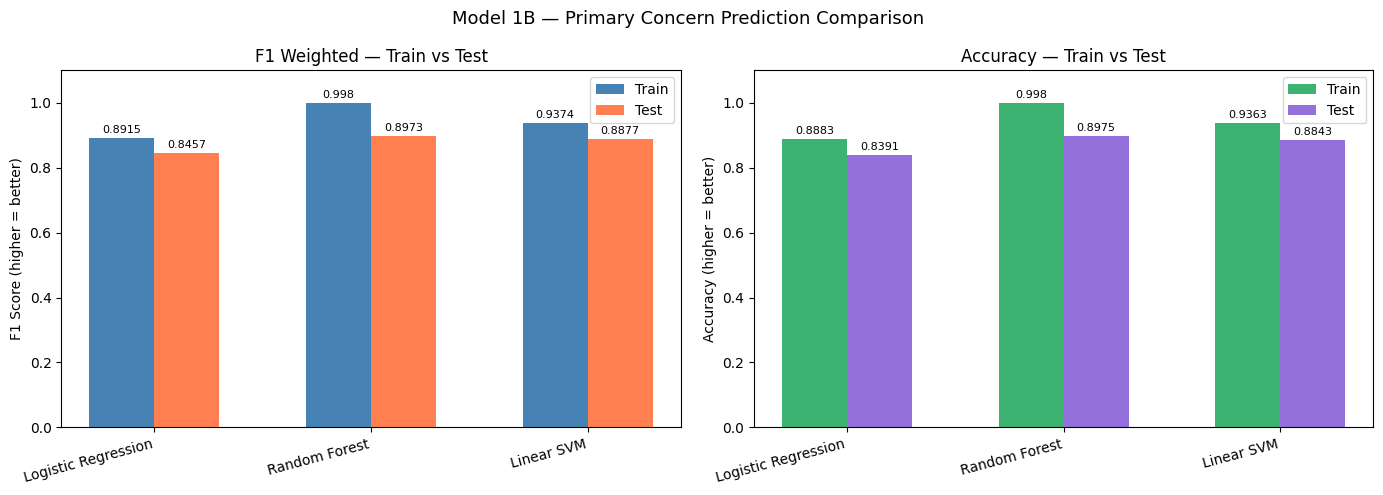


Best Test F1:       Random Forest
Best Test Accuracy: Random Forest

Overfitting check (Train F1 - Test F1):
  Logistic Regression       gap=0.0458  OK
  Random Forest             gap=0.1007  SLIGHT
  Linear SVM                gap=0.0497  OK


In [12]:


models_1B = {
    "Logistic Regression": (y_concern_pred_lr_train,  y_concern_pred_lr_test),
    "Random Forest":       (y_concern_pred_rf_train,  y_concern_pred_rf_test),
    "Linear SVM":          (y_concern_pred_svm_train, y_concern_pred_svm_test),
}


rows = []
for name, (tr_pred, te_pred) in models_1B.items():
    rows.append({
        "Model":          name,
        "Train Acc":      round(accuracy_score(y_concern_train, tr_pred), 4),
        "Test Acc":       round(accuracy_score(y_concern_test,  te_pred), 4),
        "Train F1":       round(f1_score(y_concern_train, tr_pred,
                                average='weighted', zero_division=0), 4),
        "Test F1":        round(f1_score(y_concern_test,  te_pred,
                                average='weighted', zero_division=0), 4),
        "Train F1 Macro": round(f1_score(y_concern_train, tr_pred,
                                average='macro', zero_division=0), 4),
        "Test F1 Macro":  round(f1_score(y_concern_test,  te_pred,
                                average='macro', zero_division=0), 4),
        "Test F1 W":      round(f1_score(y_concern_test, te_pred,
                                average='weighted', zero_division=0), 4),
        "Test Bal Acc":   round(balanced_accuracy_score(
                                y_concern_test, te_pred), 4),
    })

results_1B = pd.DataFrame(rows)
print(results_1B.to_string(index=False))

x     = np.arange(len(results_1B))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Weighted
axes[0].bar(x - width/2, results_1B['Train F1'], width,
            label='Train', color='steelblue')
axes[0].bar(x + width/2, results_1B['Test F1'],  width,
            label='Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_1B['Model'], rotation=15, ha='right')
axes[0].set_title('F1 Weighted — Train vs Test')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('F1 Score (higher = better)')
for i, (tr, te) in enumerate(zip(results_1B['Train F1'],
                                  results_1B['Test F1'])):
    axes[0].text(i - width/2, tr + 0.01, str(tr),
                 ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, te + 0.01, str(te),
                 ha='center', va='bottom', fontsize=8)

# Accuracy
axes[1].bar(x - width/2, results_1B['Train Acc'], width,
            label='Train', color='mediumseagreen')
axes[1].bar(x + width/2, results_1B['Test Acc'],  width,
            label='Test',  color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_1B['Model'], rotation=15, ha='right')
axes[1].set_title('Accuracy — Train vs Test')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].set_ylabel('Accuracy (higher = better)')
for i, (tr, te) in enumerate(zip(results_1B['Train Acc'],
                                  results_1B['Test Acc'])):
    axes[1].text(i - width/2, tr + 0.01, str(tr),
                 ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, te + 0.01, str(te),
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Model 1B — Primary Concern Prediction Comparison',
             fontsize=13)
plt.tight_layout()
plt.savefig('model1B_comparison.png', dpi=150)
plt.show()

best_f1  = results_1B.loc[results_1B['Test F1'].idxmax(),  'Model']
best_acc = results_1B.loc[results_1B['Test Acc'].idxmax(), 'Model']

print(f"\nBest Test F1:       {best_f1}")
print(f"Best Test Accuracy: {best_acc}")

print(f"\nOverfitting check (Train F1 - Test F1):")
for _, row in results_1B.iterrows():
    gap  = round(row['Train F1'] - row['Test F1'], 4)
    flag = "OVERFIT" if gap > 0.15 else "SLIGHT" if gap > 0.05 else "OK"
    print(f"  {row['Model']:<25} gap={gap}  {flag}")

### **Initial model choice**
comparing the three models we find that svm linear showed the best f1 score as well as the lowest overfitting gap -->svm is chosen as primary model

## **Cross validation**

**Linear SVM**

In [13]:
from sklearn.model_selection import cross_val_score

print("Cross-Validation (5-fold) — Linear SVM Before Tuning")
print("=" * 30)

cv_scores_svm = cross_val_score(
    model_1B_svm,
    X_concern_train,
    y_concern_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

test_f1 = f1_score(y_concern_test, y_concern_pred_svm_test,
                   average='weighted', zero_division=0)

print(f"  CV F1 per fold: {[round(float(s), 4) for s in cv_scores_svm]}")
print(f"  Mean CV F1:     {cv_scores_svm.mean():.4f}")
print(f"  Std CV F1:      {cv_scores_svm.std():.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Gap (CV-Test):  {cv_scores_svm.mean() - test_f1:.4f}")
print()
if cv_scores_svm.std() < 0.01:
    print("  Stability: Very stable across folds")
elif cv_scores_svm.std() < 0.03:
    print("  Stability: Stable across folds")
else:
    print("  Stability: High variance — model sensitive to data split")

Cross-Validation (5-fold) — Linear SVM Before Tuning
  CV F1 per fold: [0.8891, 0.8777, 0.8869, 0.8958, 0.8808]
  Mean CV F1:     0.8861
  Std CV F1:      0.0063
  Test F1:        0.8877
  Gap (CV-Test):  -0.0016

  Stability: Very stable across folds


The 5-fold cross-validation results for the Linear SVM model show consistent performance across all folds,the model generalizes well to unseen data and is not overfitting

## **randomized search**

### **logistic regression**

In [14]:
from sklearn.model_selection import RandomizedSearchCV
param_lr = {
    'C':        loguniform(0.001, 100),
    'max_iter': [500, 1000, 2000]
}

lr_search_concern = RandomizedSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        random_state=42,
        multi_class='multinomial'
    ),
    param_distributions=param_lr,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lr_search_concern.fit(X_concern_train, y_concern_train)

print("LOGISTIC REGRESSION TUNING")
print(f"  Best C:      {lr_search_concern.best_params_['C']:.4f}")
print(f"  Best CV F1:  {lr_search_concern.best_score_:.4f}")

y_concern_pred_lr_train = lr_search_concern.predict(X_concern_train)
y_concern_pred_lr_test  = lr_search_concern.predict(X_concern_test)

print("\nTraining Performance:")
evaluate_multiclass(y_concern_train, y_concern_pred_lr_train,
                    "LR Tuned - Train", concern_classes)
print("Testing Performance:")
evaluate_multiclass(y_concern_test, y_concern_pred_lr_test,
                    "LR Tuned - Test", concern_classes)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LOGISTIC REGRESSION TUNING
  Best C:      82.4431
  Best CV F1:  0.8702

Training Performance:
  Model:        LR Tuned - Train
  Accuracy:     0.9683
  Balanced Accuracy:  0.9781
  F1 Weighted:  0.9686
  F1 Macro:     0.9612

  Acne                 F1: 0.981
  Dryness              F1: 0.956
  Eczema               F1: 0.974
  Hyperpigmentation    F1: 0.957
  Redness              F1: 0.958
  Sensitivity          F1: 0.942

Testing Performance:
  Model:        LR Tuned - Test
  Accuracy:     0.8775
  Balanced Accuracy:  0.8355
  F1 Weighted:  0.8794
  F1 Macro:     0.8183

  Acne                 F1: 0.953
  Dryness              F1: 0.640
  Eczema               F1: 0.875
  Hyperpigmentation    F1: 0.836
  Redness              F1: 0.822
  Sensitivity          F1: 0.785



### **random forest**

In [15]:

param_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf':  randint(1, 5),
    'max_features':      ['sqrt', 'log2']
}

rf_search_concern = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_rf,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search_concern.fit(X_concern_train, y_concern_train)

print("RANDOM FOREST TUNING")
print(f"  Best params: {rf_search_concern.best_params_}")
print(f"  Best CV F1:  {rf_search_concern.best_score_:.4f}")

y_concern_pred_rf_train = rf_search_concern.predict(X_concern_train)
y_concern_pred_rf_test  = rf_search_concern.predict(X_concern_test)

print("\nTraining Performance:")
evaluate_multiclass(y_concern_train, y_concern_pred_rf_train,
                    "RF Tuned - Train", concern_classes)
print("Testing Performance:")
evaluate_multiclass(y_concern_test, y_concern_pred_rf_test,
                    "RF Tuned - Test", concern_classes)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RANDOM FOREST TUNING
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 300}
  Best CV F1:  0.8862

Training Performance:
  Model:        RF Tuned - Train
  Accuracy:     0.9803
  Balanced Accuracy:  0.9867
  F1 Weighted:  0.9803
  F1 Macro:     0.9788

  Acne                 F1: 0.984
  Dryness              F1: 0.977
  Eczema               F1: 0.985
  Hyperpigmentation    F1: 0.974
  Redness              F1: 0.979
  Sensitivity          F1: 0.974

Testing Performance:
  Model:        RF Tuned - Test
  Accuracy:     0.8980
  Balanced Accuracy:  0.8430
  F1 Weighted:  0.9000
  F1 Macro:     0.8485

  Acne                 F1: 0.971
  Dryness              F1: 0.756
  Eczema               F1: 0.913
  Hyperpigmentation    F1: 0.851
  Redness              F1: 0.833
  Sensitivity          F1: 0.767



### **SVM linear**

In [16]:

param_svm = {
    'C':        loguniform(0.001, 100),
    'max_iter': [1000, 2000, 5000]
}

svm_search_concern = RandomizedSearchCV(
    estimator=LinearSVC(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=param_svm,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
svm_search_concern.fit(X_concern_train, y_concern_train)

print("LINEAR SVM TUNING")
print(f"  Best C:      {svm_search_concern.best_params_['C']:.4f}")
print(f"  Best CV F1:  {svm_search_concern.best_score_:.4f}")

y_concern_pred_svm_train = svm_search_concern.predict(X_concern_train)
y_concern_pred_svm_test  = svm_search_concern.predict(X_concern_test)

print("\nTraining Performance:")
evaluate_multiclass(y_concern_train, y_concern_pred_svm_train,
                    "SVM Tuned - Train", concern_classes)
print("Testing Performance:")
evaluate_multiclass(y_concern_test, y_concern_pred_svm_test,
                    "SVM Tuned - Test", concern_classes)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
LINEAR SVM TUNING
  Best C:      2.5208
  Best CV F1:  0.8892

Training Performance:
  Model:        SVM Tuned - Train
  Accuracy:     0.9468
  Balanced Accuracy:  0.9484
  F1 Weighted:  0.9475
  F1 Macro:     0.9294

  Acne                 F1: 0.975
  Dryness              F1: 0.913
  Eczema               F1: 0.946
  Hyperpigmentation    F1: 0.931
  Redness              F1: 0.912
  Sensitivity          F1: 0.900

Testing Performance:
  Model:        SVM Tuned - Test
  Accuracy:     0.8901
  Balanced Accuracy:  0.8476
  F1 Weighted:  0.8929
  F1 Macro:     0.8307

  Acne                 F1: 0.966
  Dryness              F1: 0.671
  Eczema               F1: 0.904
  Hyperpigmentation    F1: 0.853
  Redness              F1: 0.828
  Sensitivity          F1: 0.762



### **confusion matrix Linear SVM**

### **Comparaison**

              Model  Train Acc  Test Acc  Train F1  Test F1
Logistic Regression     0.9683    0.8775    0.9686   0.8794
      Random Forest     0.9803    0.8980    0.9803   0.9000
         Linear SVM     0.9468    0.8901    0.9475   0.8929


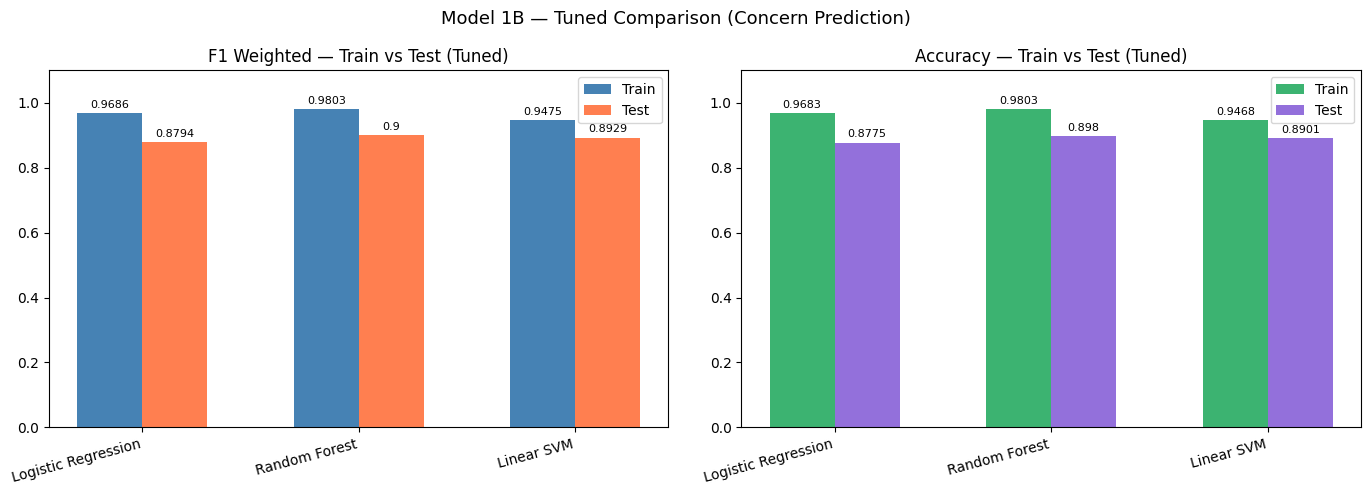


Best Test F1: Random Forest

Overfitting check (Train F1 - Test F1):
  Logistic Regression       gap=0.0892  SLIGHT
  Random Forest             gap=0.0803  SLIGHT
  Linear SVM                gap=0.0546  SLIGHT


In [17]:
#comparaison
models_1B_tuned = {
    "Logistic Regression": (y_concern_pred_lr_train,  y_concern_pred_lr_test),
    "Random Forest":       (y_concern_pred_rf_train,  y_concern_pred_rf_test),
    "Linear SVM":          (y_concern_pred_svm_train, y_concern_pred_svm_test),
}

rows = []
for name, (tr_pred, te_pred) in models_1B_tuned.items():
    rows.append({
        "Model":      name,
        "Train Acc":  round(accuracy_score(y_concern_train, tr_pred), 4),
        "Test Acc":   round(accuracy_score(y_concern_test,  te_pred), 4),
        "Train F1":   round(f1_score(y_concern_train, tr_pred,
                            average='weighted', zero_division=0), 4),
        "Test F1":    round(f1_score(y_concern_test,  te_pred,
                            average='weighted', zero_division=0), 4),
    })

results_1B_tuned = pd.DataFrame(rows)
print(results_1B_tuned.to_string(index=False))

# Plot
x     = np.arange(len(results_1B_tuned))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1
axes[0].bar(x - width/2, results_1B_tuned['Train F1'], width,
            label='Train', color='steelblue')
axes[0].bar(x + width/2, results_1B_tuned['Test F1'],  width,
            label='Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_1B_tuned['Model'], rotation=15, ha='right')
axes[0].set_title('F1 Weighted — Train vs Test (Tuned)')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, (tr, te) in enumerate(zip(results_1B_tuned['Train F1'],
                                  results_1B_tuned['Test F1'])):
    axes[0].text(i - width/2, tr + 0.01, str(tr),
                 ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, te + 0.01, str(te),
                 ha='center', va='bottom', fontsize=8)

# Accuracy
axes[1].bar(x - width/2, results_1B_tuned['Train Acc'], width,
            label='Train', color='mediumseagreen')
axes[1].bar(x + width/2, results_1B_tuned['Test Acc'],  width,
            label='Test',  color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_1B_tuned['Model'], rotation=15, ha='right')
axes[1].set_title('Accuracy — Train vs Test (Tuned)')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, (tr, te) in enumerate(zip(results_1B_tuned['Train Acc'],
                                  results_1B_tuned['Test Acc'])):
    axes[1].text(i - width/2, tr + 0.01, str(tr),
                 ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, te + 0.01, str(te),
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Model 1B — Tuned Comparison (Concern Prediction)', fontsize=13)
plt.tight_layout()
plt.savefig('model1B_tuned_comparison.png', dpi=150)
plt.show()

# Winner
best_f1 = results_1B_tuned.loc[results_1B_tuned['Test F1'].idxmax(), 'Model']
print(f"\nBest Test F1: {best_f1}")

print(f"\nOverfitting check (Train F1 - Test F1):")
for _, row in results_1B_tuned.iterrows():
    gap  = round(row['Train F1'] - row['Test F1'], 4)
    flag = "OVERFIT" if gap > 0.15 else "SLIGHT" if gap > 0.05 else "OK"
    print(f"  {row['Model']:<25} gap={gap}  {flag}")

### **Confusion matrix random forest tuned**

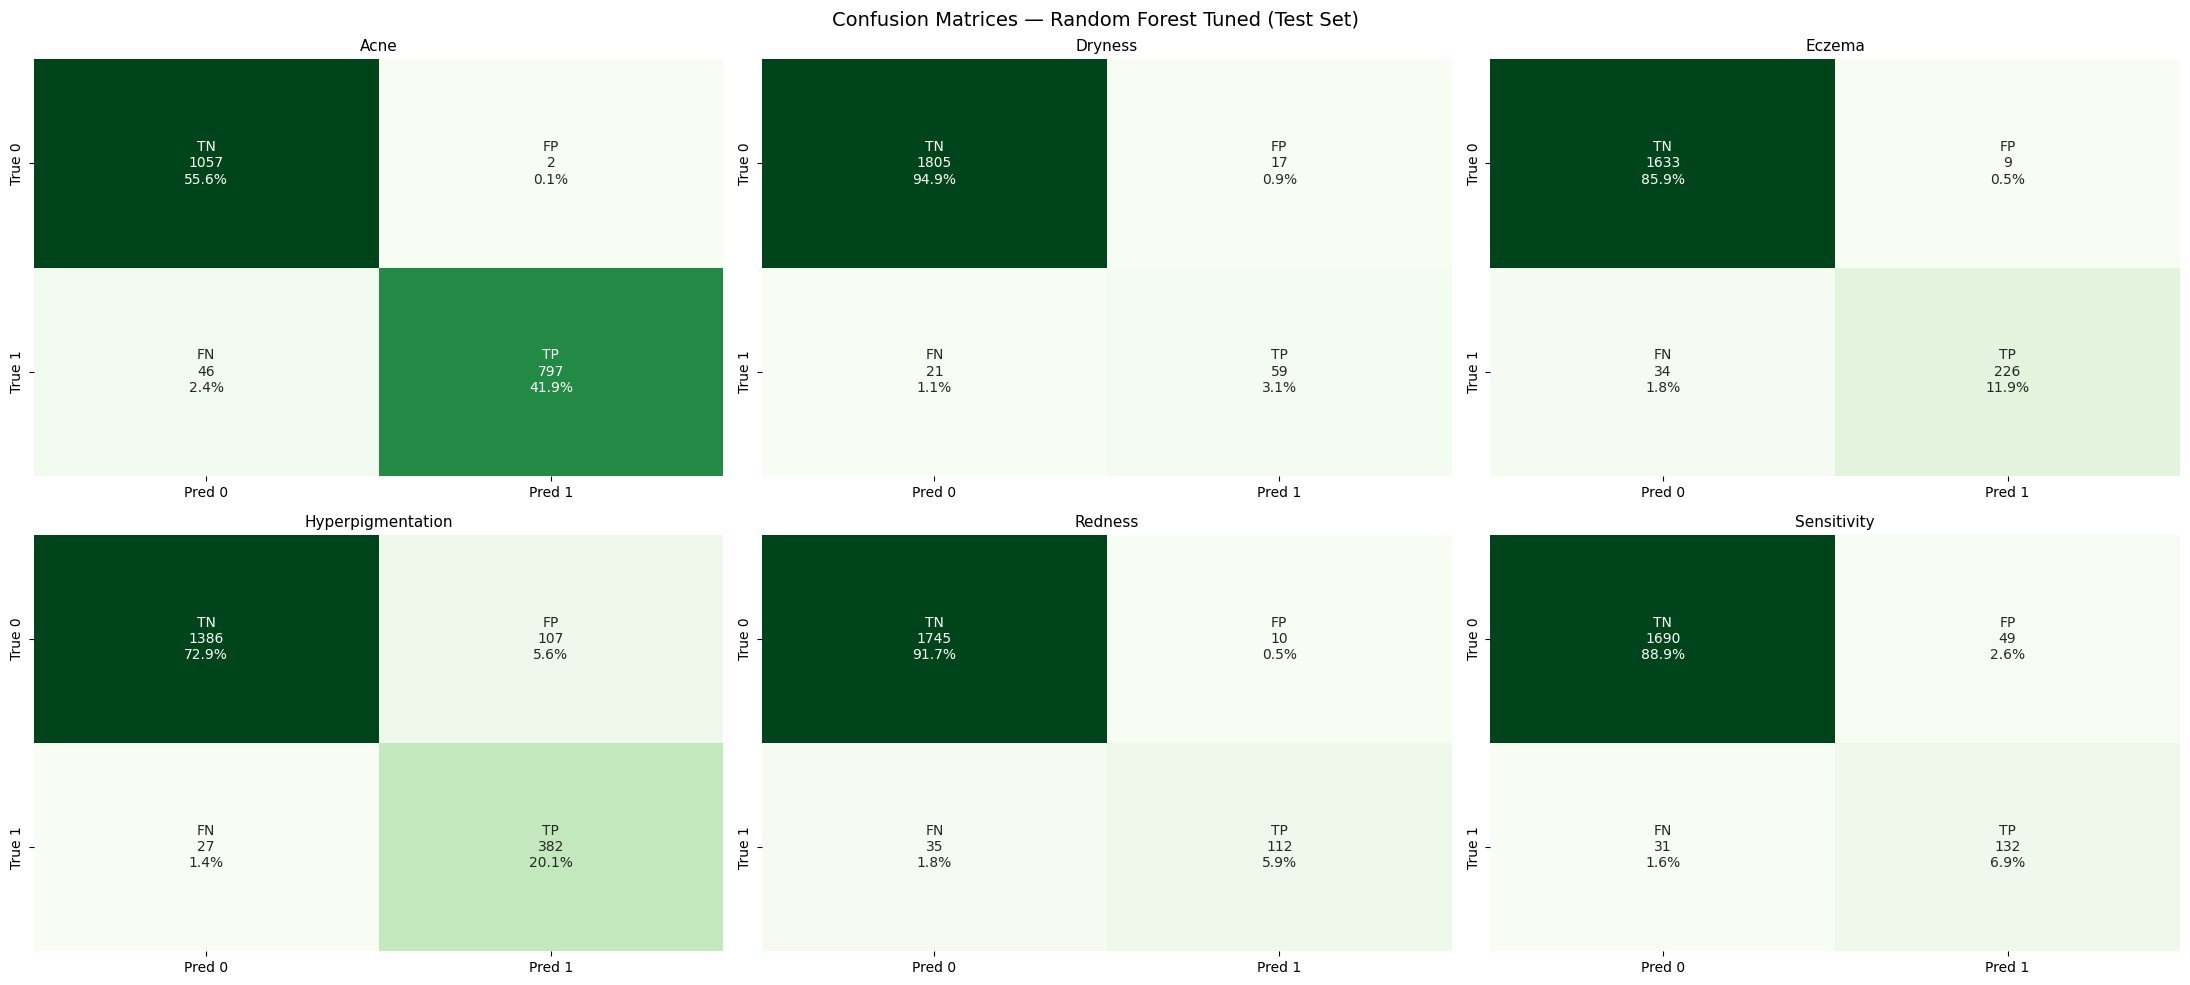

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()

for i, concern in enumerate(concern_classes):
    y_true_bin = (y_concern_test == i).astype(int)
    y_pred_bin = (y_concern_pred_rf_test == i).astype(int)  # ✅ changed here

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    group_names  = ['TN', 'FP', 'FN', 'TP']
    group_counts = [f"{v}" for v in cm.flatten()]
    group_pct    = [f"{v:.1%}" for v in cm.flatten() / cm.sum()]

    labels = [f"{n}\n{c}\n{p}" for n, c, p in zip(group_names, group_counts, group_pct)]
    labels = np.array(labels).reshape(2, 2)

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        ax=axes[i],
        cmap='Greens',  # optional: different color for RF
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1']
    )
    axes[i].set_title(f'{concern}', fontsize=11)

# Hide extra plots if needed
if len(concern_classes) < len(axes):
    for j in range(len(concern_classes), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — Random Forest Tuned (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('cm_rf_tuned.png', dpi=150)
plt.show()

The comparison of the three models shows that Random Forest achieves the best overall performance, with the highest Test F1-score and Test Accuracy.This indicates that it is the most effective model in correctly classifying the data while maintaining a good balance between precision and recall.

## Final Model: Random Forest Tuned

In [19]:
import pickle
from google.colab import files

# Get best model
best_rf_model = rf_search_concern.best_estimator_

# Save model
with open("rf_tuned_model_concern.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("Model saved as rf_tuned_model_concern.pkl")
files.download('/content/rf_tuned_model_concern.pkl')

Model saved as rf_tuned_model_concern.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>